In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("DATA\\obesity.csv")

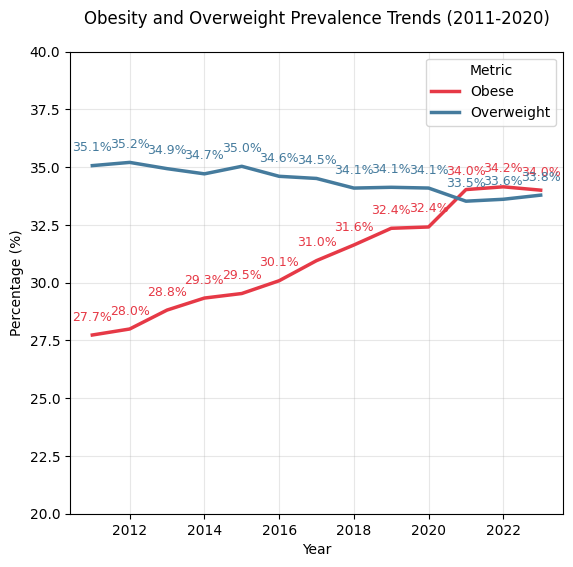

In [20]:
# Visualization 1: Obesity and Overweight Trends by Year
plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
yearly_avg = df.groupby('Year')[['Obese', 'Overweight']].mean().reset_index()
sns.lineplot(data=pd.melt(yearly_avg, ['Year']), 
             x='Year', 
             y='value', 
             hue='variable', 
             palette=['#e63946', '#457b9d'], 
             linewidth=2.5)
plt.title('Obesity and Overweight Prevalence Trends (2011-2020)', pad=20)
plt.ylabel('Percentage (%)')
plt.xlabel('Year')
plt.legend(title='Metric')
plt.ylim(20, 40)
plt.grid(True, alpha=0.3)

# Add value annotations
for col in ['Obese', 'Overweight']:
    for year, val in zip(yearly_avg['Year'], yearly_avg[col]):
        plt.text(year, val+0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='#e63946' if col == 'Obese' else '#457b9d')

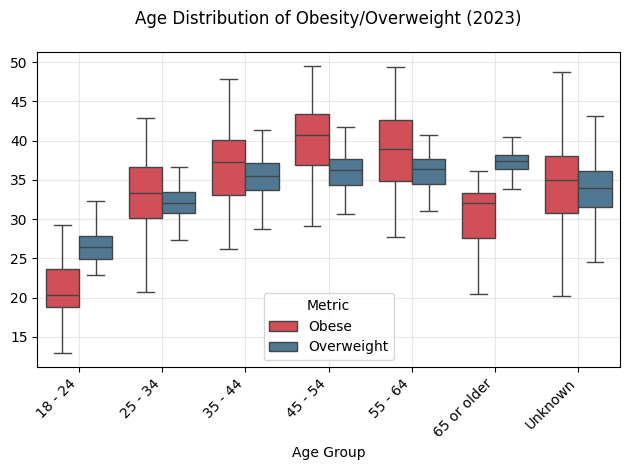

In [21]:
# Visualization 2: Demographic Breakdown (using latest year)
latest_year = df['Year'].max()
latest_data = df[df['Year'] == latest_year]

demo_plot_data = latest_data.melt(id_vars=['Age'], 
                                value_vars=['Obese', 'Overweight'],
                                var_name='Metric', 
                                value_name='Percentage')

sns.boxplot(data=demo_plot_data, 
            x='Age', 
            y='Percentage', 
            hue='Metric',
           palette=['#e63946', '#457b9d'], 
           showfliers=False)
plt.title(f'Age Distribution of Obesity/Overweight ({latest_year})', pad=20)
plt.xlabel('Age Group')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

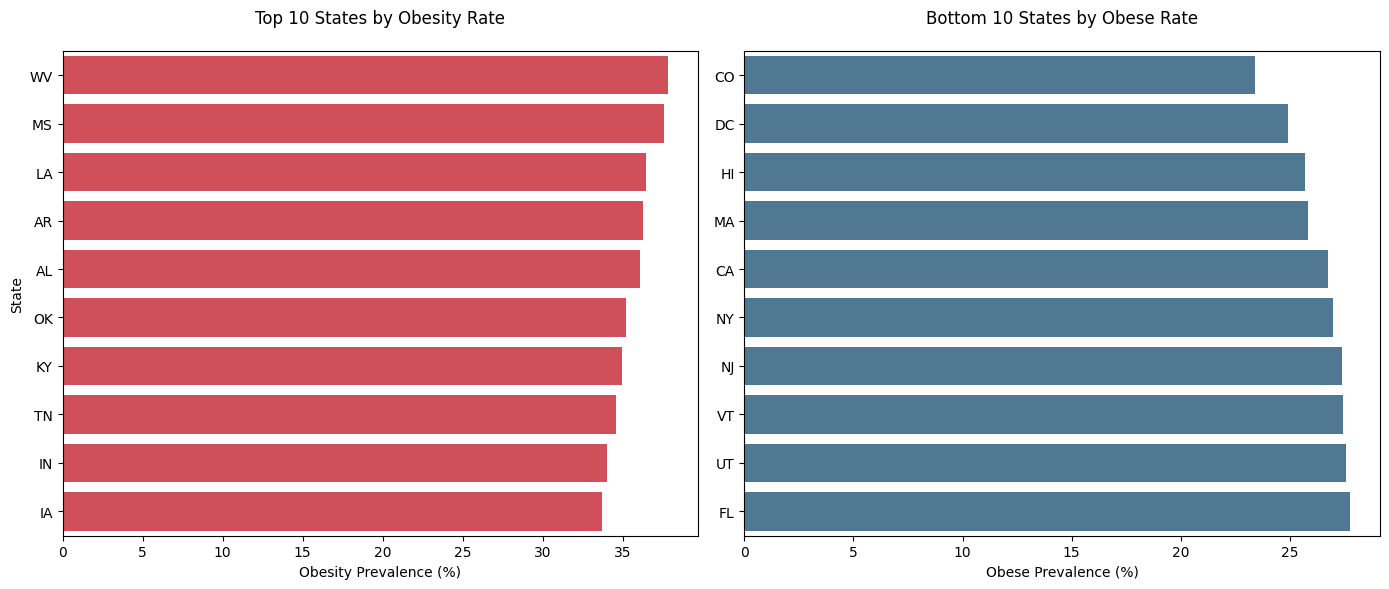

In [22]:
# Visualization 3: Geographic Variation 
plt.figure(figsize=(14, 6))
state_avg = df.groupby('StateID')[['Obese']].mean()

# Top 10 Obese States
plt.subplot(1, 2, 1)
top_obese = state_avg['Obese'].sort_values(ascending=False).head(10)
sns.barplot(x=top_obese.values, y=top_obese.index, color='#e63946')
plt.title('Top 10 States by Obesity Rate', pad=20)
plt.xlabel('Obesity Prevalence (%)')
plt.ylabel('State')

# Bottom 10 Obese States
plt.subplot(1, 2, 2)
bottom_Obese = state_avg['Obese'].sort_values().head(10)
sns.barplot(x=bottom_Obese.values, y=bottom_Obese.index, color='#457b9d')
plt.title('Bottom 10 States by Obese Rate', pad=20)
plt.xlabel('Obese Prevalence (%)')
plt.ylabel('')

plt.tight_layout()
plt.show()

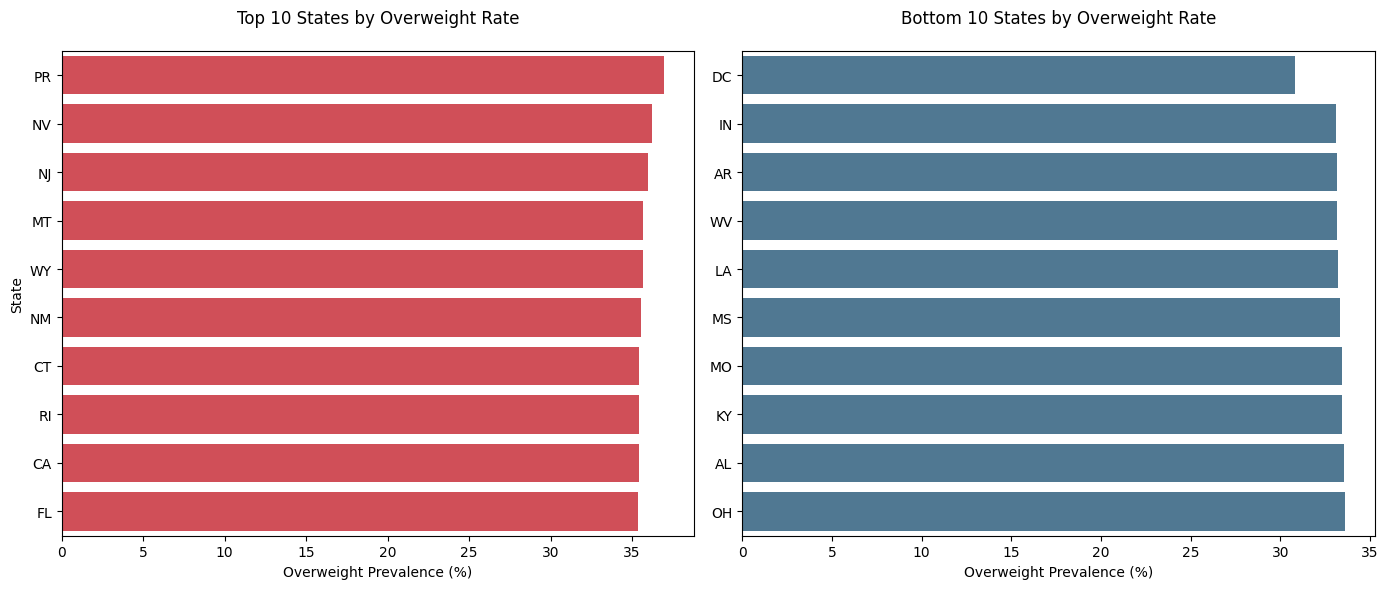

In [23]:
# Visualization 4: Geographic Variation 
plt.figure(figsize=(14, 6))
state_avg = df.groupby('StateID')[['Overweight']].mean()

# Top 10 Overweight States
plt.subplot(1, 2, 1)
top_Overweight = state_avg['Overweight'].sort_values(ascending=False).head(10)
sns.barplot(x=top_Overweight.values, y=top_Overweight.index, color='#e63946')
plt.title('Top 10 States by Overweight Rate', pad=20)
plt.xlabel('Overweight Prevalence (%)')
plt.ylabel('State')

# ottom 10 Overweight States
plt.subplot(1, 2, 2)
bottom_overweight = state_avg['Overweight'].sort_values().head(10)
sns.barplot(x=bottom_overweight.values, y=bottom_overweight.index, color='#457b9d')
plt.title('Bottom 10 States by Overweight Rate', pad=20)
plt.xlabel('Overweight Prevalence (%)')
plt.ylabel('')

plt.tight_layout()
plt.show()